**Only dataset analysis and observation is there**

Import Required Libraries

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 


Load the California Housing dataset

In [3]:
df = pd.read_csv('../dataset/housing.csv')
print(df.head(10))
print('shape of the dataframe: ', df.shape)

      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      

# **Steps to Follow the EDA on the Given dataset**



**Step1. Identify the Target Column**
 
Our Goal is to predict the prize. Target Column is Prize

Visualize the target Column 

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


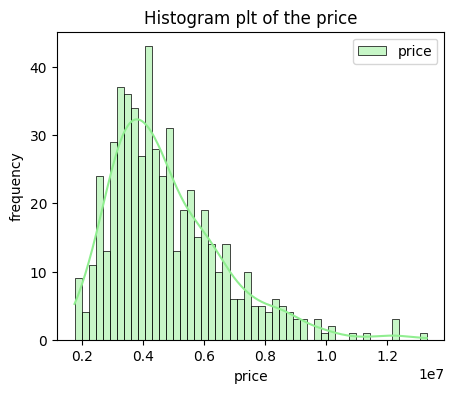

In [4]:
import matplotlib.pyplot as plt 
import seaborn as sns

print(df.columns)

plt.figure(figsize=(5,4))
sns.histplot(df['price'], label="price", bins=50, kde=True, color='lightgreen')
plt.xlabel("price")
plt.ylabel("frequency")
plt.title(f"Histogram plt of the {'price'}")
plt.legend()



Histplot of the Prize column is right skewed. 



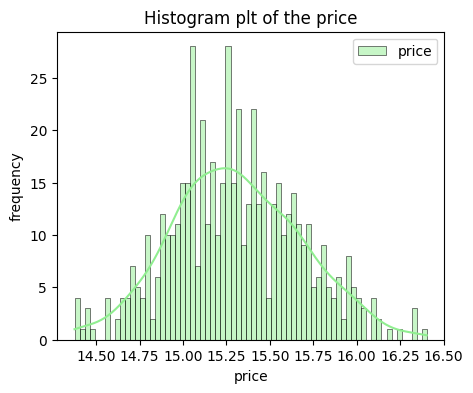

In [5]:
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

# Convert the right skewed prize column into a Normal Distribution curve
df['price'] = np.log1p(df['price'])

plt.figure(figsize=(5,4))
sns.histplot(df['price'], label="price", bins=70, kde=True, color='lightgreen')
plt.xlabel("price")
plt.ylabel("frequency")
plt.title(f"Histogram plt of the {'price'}")
plt.legend()

# Outlier check is pending

**Step 2. Missing Value Analysis**

In [6]:
# Check Null Values inside the dataset 

# No null Value is there in each column and no need to do further
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

**Step3. Check Duplicate Row**

In [7]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

**Step4. Numerical Feature EDA**

Filter out the Numerical column and categorical column

In [8]:
# Check the datatype of each feature(column)
df.info()
print(len(df.columns))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             545 non-null    float64
 1   area              545 non-null    int64  
 2   bedrooms          545 non-null    int64  
 3   bathrooms         545 non-null    int64  
 4   stories           545 non-null    int64  
 5   mainroad          545 non-null    object 
 6   guestroom         545 non-null    object 
 7   basement          545 non-null    object 
 8   hotwaterheating   545 non-null    object 
 9   airconditioning   545 non-null    object 
 10  parking           545 non-null    int64  
 11  prefarea          545 non-null    object 
 12  furnishingstatus  545 non-null    object 
dtypes: float64(1), int64(5), object(7)
memory usage: 55.5+ KB
13


In [9]:
# -----------------------------------------------------------------------------
# =================== || Filtered Numerical and Categorical Column || =====================
# -----------------------------------------------------------------------------
numerical_feature = df.select_dtypes("int64")
categorical_feature = df.select_dtypes("object")

print('Numerical features: ', numerical_feature.columns)

print('Categorical Feature: ', categorical_feature.columns)

Numerical features:  Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')
Categorical Feature:  Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


**Step5. Coorelation Analysis**

In [10]:
# -----------------------------------------------------------------------------
# =================== || COORELATION MATRIX || =====================
# -----------------------------------------------------------------------------
correlationMatrix = df.select_dtypes(include='number').corr()

print(correlationMatrix)

# In the below table there is no extremely low correlated column. All are affecting the prize so no need to remove.

              price      area  bedrooms  bathrooms   stories   parking
price      1.000000  0.543233  0.369986   0.485715  0.415281  0.371638
area       0.543233  1.000000  0.151858   0.193820  0.083996  0.352980
bedrooms   0.369986  0.151858  1.000000   0.373930  0.408564  0.139270
bathrooms  0.485715  0.193820  0.373930   1.000000  0.326165  0.177496
stories    0.415281  0.083996  0.408564   0.326165  1.000000  0.045547
parking    0.371638  0.352980  0.139270   0.177496  0.045547  1.000000


Analysis of the Categorical feature column 

In [11]:
# -----------------------------------------------------------------------------
# =================== || CATEGORICAL COLUMNS ANALYSIS || =====================
# -----------------------------------------------------------------------------

categorical_feature = df.select_dtypes("object")

for col in categorical_feature.columns:
    means = df.groupby(col)['price'].mean() 
    print(f'{col}: ',means )
    print('difference: ',means.max()- means.min())
    print('-')

# -----------------------------------------------------------------------------
# difference:
# Difference	Interpretation
# > 0.30	Strong feature
# 0.15 - 0.30	Moderate
# < 0.15	Weak

# ------------------------------------------------------------------------------
# so we are removing the hotwaterheating columns
# ------------------------------------------------------------------------------

mainroad:  mainroad
no     15.004448
yes    15.356764
Name: price, dtype: float64
difference:  0.35231639709597573
-
guestroom:  guestroom
no     15.259054
yes    15.528370
Name: price, dtype: float64
difference:  0.26931573275613196
-
basement:  basement
no     15.247338
yes    15.417542
Name: price, dtype: float64
difference:  0.17020409412752358
-
hotwaterheating:  hotwaterheating
no     15.299734
yes    15.457857
Name: price, dtype: float64
difference:  0.1581237342915749
-
airconditioning:  airconditioning
no     15.192063
yes    15.556211
Name: price, dtype: float64
difference:  0.36414817591928994
-
prefarea:  prefarea
no     15.236831
yes    15.535541
Name: price, dtype: float64
difference:  0.2987100441017674
-
furnishingstatus:  furnishingstatus
furnished         15.450529
semi-furnished    15.359890
unfurnished       15.126622
Name: price, dtype: float64
difference:  0.3239070488886746
-


Drop a weak Column

In [12]:
df.drop(columns=['hotwaterheating'], inplace=True)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             545 non-null    float64
 1   area              545 non-null    int64  
 2   bedrooms          545 non-null    int64  
 3   bathrooms         545 non-null    int64  
 4   stories           545 non-null    int64  
 5   mainroad          545 non-null    object 
 6   guestroom         545 non-null    object 
 7   basement          545 non-null    object 
 8   airconditioning   545 non-null    object 
 9   parking           545 non-null    int64  
 10  prefarea          545 non-null    object 
 11  furnishingstatus  545 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 51.2+ KB
None


# Feature Scaling

In [13]:
# Follow Standard Scaler
print(df.sample(10))

         price  area  bedrooms  bathrooms  stories mainroad guestroom  \
324  15.203678  4500         3          1        2       no        no   
14   16.039053  7800         3          2        2      yes        no   
363  15.126543  3584         2          1        1      yes        no   
453  14.962913  3069         2          1        1      yes        no   
451  14.962913  6750         2          1        1      yes        no   
413  15.048071  1950         3          2        2      yes        no   
40   15.879204  6550         3          1        2      yes        no   
524  14.682611  3264         2          1        1      yes        no   
9    16.097893  5750         3          2        4      yes       yes   
380  15.097833  4500         2          1        1      yes        no   

    basement airconditioning  parking prefarea furnishingstatus  
324      yes             yes        0       no   semi-furnished  
14        no              no        0      yes   semi-furnished 

Convert Categorical Data into Numerical Data

categorical columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating','airconditioning', 'prefarea', 'furnishingsatus']

Only furnishingsatus is Ordinal columns unfurnished < semi furnished < Furnished
Other are only Nominal Columns

For Nominal Categorical Columns: One Hot Encoding 
For Ordinal Categorical Columns: 

HeatMap Plot

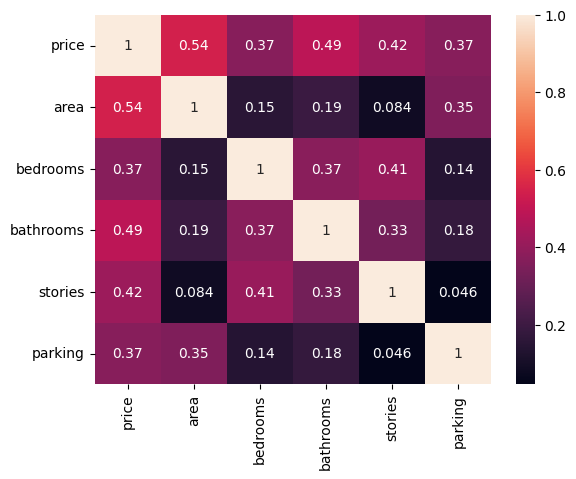

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(correlationMatrix, annot=True)
plt.show()